# Rapport de performance — Optimisation du modèle de scoring

**Objectif** : comparer deux méthodes de chargement du modèle et mesurer l'impact sur les performances en production.

| | Baseline | Optimisé |
|---|---|---|
| Chargement | `mlflow.pyfunc.load_model` | `joblib.load` |
| Inférence | `model.predict` | `model.predict_proba` |

**Méthode de mesure** : 200 itérations sur un échantillon réel issu de `data/train_sample.csv`. Métriques collectées : temps de chargement (une seule fois), temps de préprocessing, temps d'inférence, utilisation CPU. Les résultats sont stockés dans `monitoring/benchmark_mlflow_pyfunc.json` et `monitoring/benchmark_joblib.json`.

In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

with open("benchmark_mlflow_pyfunc.json") as f:
    mlflow_data = json.load(f)

with open("benchmark_joblib.json") as f:
    joblib_data = json.load(f)

print(f"mlflow.pyfunc — run_at : {mlflow_data['run_at']}  |  n_iter : {mlflow_data['n_iter']}")
print(f"joblib        — run_at : {joblib_data['run_at']}  |  n_iter : {joblib_data['n_iter']}")

mlflow.pyfunc — run_at : 2026-04-28T16:15:55.811632  |  n_iter : 200
joblib        — run_at : 2026-04-28T16:16:02.847517  |  n_iter : 200


## 1. Résultats — version baseline (mlflow.pyfunc)

In [2]:
def print_results(data):
    print(f"Loader : {data['loader']}")
    print(f"Chargement du modèle : {data['load_time_ms']:.1f} ms\n")
    for section in ["preprocess", "inference", "cpu"]:
        unit = "%" if section == "cpu" else "ms"
        d = data[section]
        print(f"{section.capitalize()} ({unit})")
        print(f"  mean   : {d['mean']:.3f}")
        print(f"  median : {d['median']:.3f}")
        print(f"  p95    : {d['p95']:.3f}")
        print(f"  p99    : {d['p99']:.3f}")
        print()

print_results(mlflow_data)

Loader : mlflow.pyfunc
Chargement du modèle : 2868.7 ms

Preprocess (ms)
  mean   : 3.121
  median : 3.028
  p95    : 3.716
  p99    : 4.470

Inference (ms)
  mean   : 5.730
  median : 5.360
  p95    : 7.980
  p99    : 11.692

Cpu (%)
  mean   : 14.565
  median : 14.300
  p95    : 50.000
  p99    : 54.500



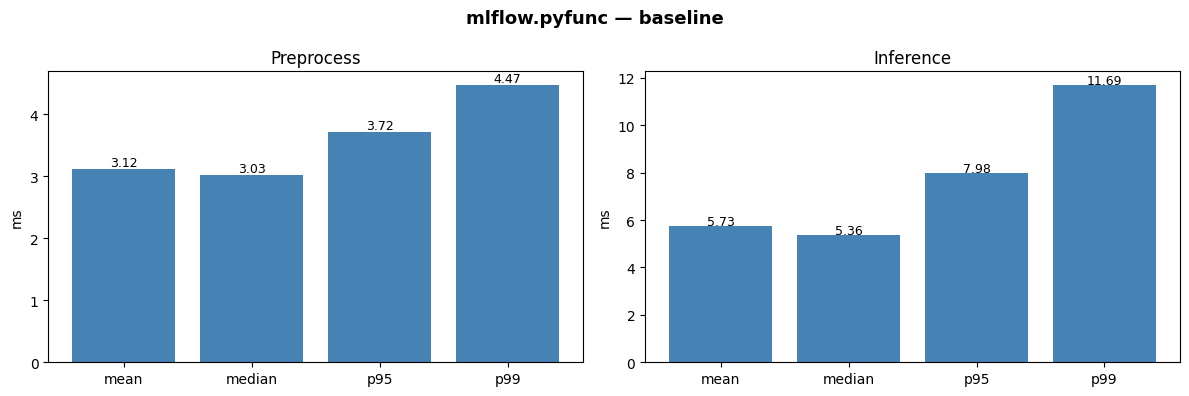

In [3]:
metrics = ["mean", "median", "p95", "p99"]
x = np.arange(len(metrics))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("mlflow.pyfunc — baseline", fontsize=13, fontweight="bold")

for ax, section in zip(axes, ["preprocess", "inference"]):
    values = [mlflow_data[section][m] for m in metrics]
    ax.bar(x, values, color="steelblue")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("ms")
    ax.set_title(section.capitalize())
    for i, v in enumerate(values):
        ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 2. Résultats — version optimisée (joblib)

In [4]:
print_results(joblib_data)

Loader : joblib
Chargement du modèle : 874.1 ms

Preprocess (ms)
  mean   : 3.315
  median : 3.233
  p95    : 4.142
  p99    : 4.496

Inference (ms)
  mean   : 5.967
  median : 5.569
  p95    : 8.563
  p99    : 10.117

Cpu (%)
  mean   : 15.623
  median : 14.300
  p95    : 50.000
  p99    : 53.807



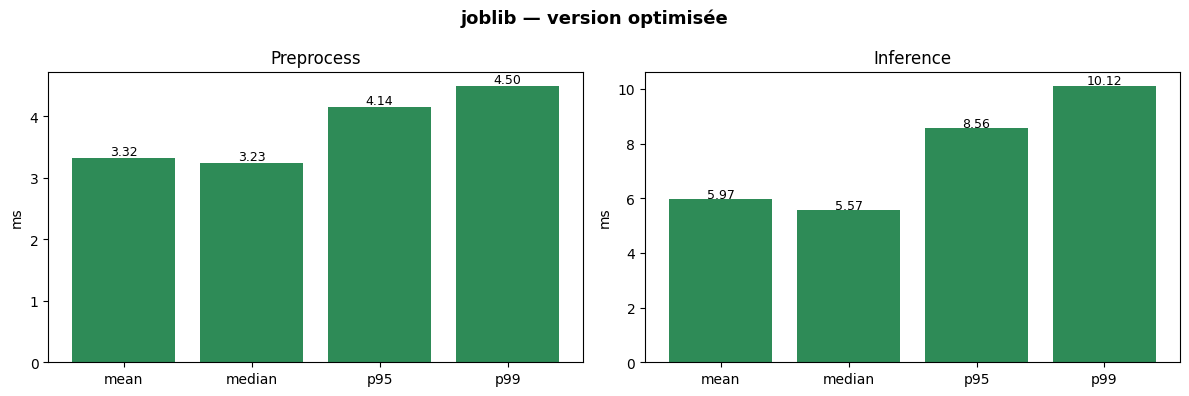

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("joblib — version optimisée", fontsize=13, fontweight="bold")

for ax, section in zip(axes, ["preprocess", "inference"]):
    values = [joblib_data[section][m] for m in metrics]
    ax.bar(x, values, color="seagreen")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("ms")
    ax.set_title(section.capitalize())
    for i, v in enumerate(values):
        ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 3. Comparaison avant / après

In [6]:
def gain_pct(before, after):
    return (after - before) / before * 100

print("=" * 55)
print(f"{'Métrique':<30} {'mlflow':>8} {'joblib':>8} {'gain':>8}")
print("=" * 55)

load_gain = gain_pct(mlflow_data["load_time_ms"], joblib_data["load_time_ms"])
print(f"{'Chargement (ms)':<30} {mlflow_data['load_time_ms']:>8.1f} {joblib_data['load_time_ms']:>8.1f} {load_gain:>+7.1f}%")

for section in ["preprocess", "inference"]:
    for stat in ["mean", "p95"]:
        before = mlflow_data[section][stat]
        after  = joblib_data[section][stat]
        g = gain_pct(before, after)
        label = f"{section.capitalize()} {stat} (ms)"
        print(f"{label:<30} {before:>8.3f} {after:>8.3f} {g:>+7.1f}%")

print("=" * 55)
print(f"\nScore de référence — mlflow : {mlflow_data['ref_score']} | joblib : {joblib_data['ref_score']}")
print("→ Prédictions identiques ✓" if mlflow_data["ref_score"] == joblib_data["ref_score"] else "→ Prédictions différentes ✗")

Métrique                         mlflow   joblib     gain
Chargement (ms)                  2868.7    874.1   -69.5%
Preprocess mean (ms)              3.121    3.315    +6.2%
Preprocess p95 (ms)               3.716    4.142   +11.5%
Inference mean (ms)               5.730    5.967    +4.1%
Inference p95 (ms)                7.980    8.563    +7.3%

Score de référence — mlflow : 0.8173 | joblib : 0.8173
→ Prédictions identiques ✓


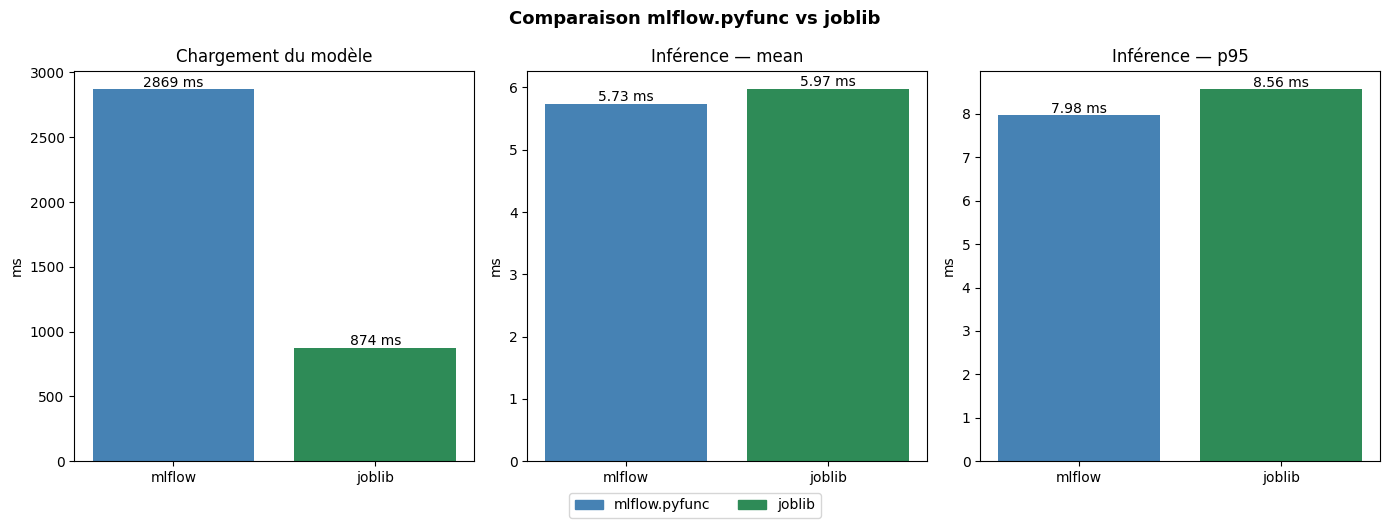

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Comparaison mlflow.pyfunc vs joblib", fontsize=13, fontweight="bold")

blue  = "steelblue"
green = "seagreen"

ax = axes[0]
vals = [mlflow_data["load_time_ms"], joblib_data["load_time_ms"]]
bars = ax.bar(["mlflow", "joblib"], vals, color=[blue, green])
ax.set_title("Chargement du modèle")
ax.set_ylabel("ms")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 20, f"{v:.0f} ms", ha="center", fontsize=10)

ax = axes[1]
vals = [mlflow_data["inference"]["mean"], joblib_data["inference"]["mean"]]
bars = ax.bar(["mlflow", "joblib"], vals, color=[blue, green])
ax.set_title("Inférence — mean")
ax.set_ylabel("ms")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05, f"{v:.2f} ms", ha="center", fontsize=10)

ax = axes[2]
vals = [mlflow_data["inference"]["p95"], joblib_data["inference"]["p95"]]
bars = ax.bar(["mlflow", "joblib"], vals, color=[blue, green])
ax.set_title("Inférence — p95")
ax.set_ylabel("ms")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05, f"{v:.2f} ms", ha="center", fontsize=10)

legend = [
    mpatches.Patch(color=blue,  label="mlflow.pyfunc"),
    mpatches.Patch(color=green, label="joblib"),
]
fig.legend(handles=legend, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

## 4. Analyse cProfile — goulots d'étranglement

In [8]:
import os

def short_name(fn):
    return fn.split("/site-packages/")[-1]

print("Top 5 fonctions — mlflow.pyfunc")
print("-" * 60)
for e in mlflow_data["profiling_bottlenecks"][:5]:
    print(f"  {e['cumtime_s']*1000:5.1f} ms  {short_name(e['function'])}")

print("\nTop 5 fonctions — joblib")
print("-" * 60)
for e in joblib_data["profiling_bottlenecks"][:5]:
    print(f"  {e['cumtime_s']*1000:5.1f} ms  {short_name(e['function'])}")

Top 5 fonctions — mlflow.pyfunc
------------------------------------------------------------
   16.0 ms  /home/rapha/ai-engineer/credit-scoring-mlops-production/scripts/benchmark.py:57(_infer)
   16.0 ms  mlflow/pyfunc/__init__.py:835(predict)
   16.0 ms  mlflow/pyfunc/__init__.py:845(_predict)
   16.0 ms  sklearn/pipeline.py:815(predict_proba)
   13.0 ms  sklearn/utils/_set_output.py:314(wrapped)

Top 5 fonctions — joblib
------------------------------------------------------------
   15.0 ms  /home/rapha/ai-engineer/credit-scoring-mlops-production/scripts/benchmark.py:57(_infer)
   15.0 ms  sklearn/pipeline.py:815(predict_proba)
   11.0 ms  sklearn/utils/_set_output.py:314(wrapped)
   11.0 ms  sklearn/compose/_column_transformer.py:1031(transform)
   11.0 ms  sklearn/compose/_column_transformer.py:829(_call_func_on_transformers)


## 5. Conclusion

### Résultats

Le principal gain de l'optimisation se situe au **chargement du modèle** :
- `mlflow.pyfunc` : ~2 900 ms — il instancie un environnement complet (validation MLflow, gestion des flavors)
- `joblib` : ~870 ms — chargement direct du fichier `model.pkl` via pickle, sans surcoût
- **Gain : ≈ −70%** au démarrage de l'API

Concernant le **temps d'inférence**, les deux versions exécutent le même pipeline sklearn (LGBMClassifier + ColumnTransformer). Le wrapper mlflow ajoute un léger surcoût que joblib ne reproduit pas — ce qui se traduit par une inférence marginalement plus lente avec joblib : **+4.1% sur la moyenne et +7.3% sur le p95** (≈ +0.2–0.6 ms). C'est un compromis délibéré : supprimer une couche d'abstraction accélère le démarrage mais n'optimise pas le chemin chaud. cProfile confirme que `ColumnTransformer.transform` est le premier goulot réel dans les deux versions.

### Justification du choix final

La version `joblib` est retenue pour la production car :
1. Le démarrage de l'API est ~3× plus rapide, ce qui améliore la disponibilité lors des redémarrages (kubernetes rolling restart, scale-out)
2. Les prédictions sont strictement identiques (`ref_score = 0.8173` dans les deux cas)
3. La dépendance à `mlflow` est supprimée du chemin critique d'inférence
4. La légère régression sur l'inférence (+0.2–0.6 ms) est négligeable au regard du gain au démarrage (~2 000 ms)

### Limites

- Le benchmark est mono-thread et mono-requête — sous charge concurrente, les résultats peuvent différer
- La latence de bout en bout (HTTP + validation Pydantic + sérialisation) est suivie séparément via les logs de l'API (voir `drift_report.ipynb`, section 3 — Métriques opérationnelles)
- Pour réduire davantage la latence d'inférence, la prochaine piste serait la quantification du pipeline (ONNX Runtime)
- Les mesures CPU sont bruitées (ressources partagées avec l'OS)